# Module 4 — Credit Demand Forecast

**Business Question:** What is the monthly loan demand for each credit grade (A, B, C, D, E) over the next quarter?

**Task Type:** Multi-output Time Series Regression
- Target: Monthly `funded_amnt` per loan grade

**Why this module is unique:**
Instead of forecasting total volume, we segment by loan grade.
This gives business teams actionable intelligence — e.g. should we
allocate more capital to Grade A (low risk) or Grade D (high yield)?

**Models compared:**
1. Linear Regression (baseline)
2. Random Forest Regressor
3. XGBoost Regressor (champion)

**Pipeline:**
```
Load processed data → Aggregate by grade + month → Engineer lag features →
Train/test split → Train 3 models per grade → Evaluate (RMSE, MAPE) →
Forecast next quarter → Visualise demand by grade
```

## 1. Import Libraries

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
os.chdir(r'C:\Users\User\Documents\finsight-forecasting')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

# Model saving
import joblib

print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load Data and Aggregate by Grade + Month

In [2]:
df = pd.read_csv('data/processed/loans_cleaned.csv', low_memory=False)
df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')
df['month_start'] = df['issue_d'].dt.to_period('M').dt.to_timestamp()

# Focus on top 5 grades: A, B, C, D, E
GRADES = ['A', 'B', 'C', 'D', 'E']
df = df[df['grade'].isin(GRADES)]

# Aggregate funded_amnt by grade and month
grade_monthly = (
    df.groupby(['month_start', 'grade'])
    .agg(
        funded_amnt  = ('funded_amnt', 'sum'),
        loan_count   = ('loan_amnt',   'count'),
        avg_int_rate = ('int_rate',    'mean'),
    )
    .reset_index()
    .sort_values(['grade', 'month_start'])
)

# Convert to millions
grade_monthly['funded_amnt_m'] = grade_monthly['funded_amnt'] / 1_000_000

print(f'Grade monthly shape: {grade_monthly.shape}')
print(f'Grades: {grade_monthly["grade"].unique()}')
print(f'Date range: {grade_monthly["month_start"].min()} → {grade_monthly["month_start"].max()}')
grade_monthly.head()

Grade monthly shape: (688, 6)
Grades: ['A' 'B' 'C' 'D' 'E']
Date range: 2007-06-01 00:00:00 → 2018-12-01 00:00:00


,month_start,grade,funded_amnt,loan_count,avg_int_rate,funded_amnt_m
1,2007-07-01,A,64050.0,13,7.748462,0.06405
4,2007-08-01,A,45000.0,10,7.686000,0.04500
9,2007-09-01,A,31500.0,5,7.688000,0.03150
13,2007-10-01,A,47700.0,8,7.830000,0.04770
18,2007-11-01,A,66950.0,11,7.779091,0.06695


## 3. Visualise Demand by Grade

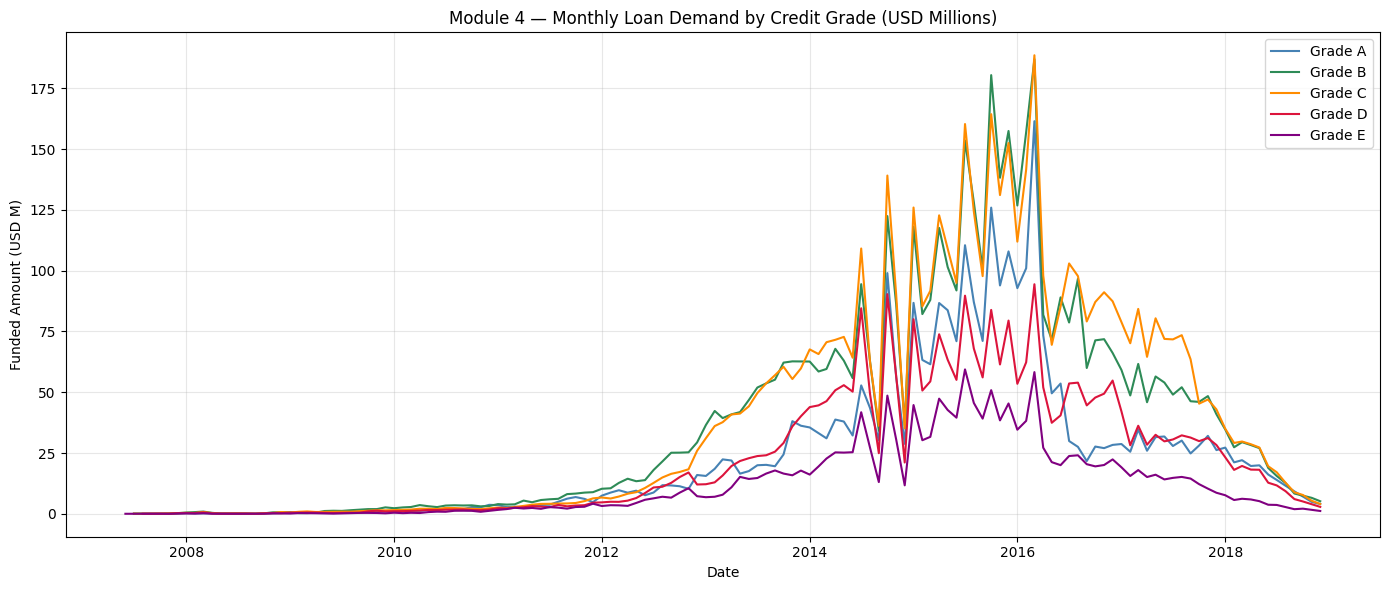

Grade demand plot saved to reports/


In [3]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = {'A': 'steelblue', 'B': 'seagreen', 'C': 'darkorange', 'D': 'crimson', 'E': 'purple'}

for grade in GRADES:
    gdf = grade_monthly[grade_monthly['grade'] == grade]
    ax.plot(gdf['month_start'], gdf['funded_amnt_m'],
            label=f'Grade {grade}', color=colors[grade], linewidth=1.5)

ax.set_title('Module 4 — Monthly Loan Demand by Credit Grade (USD Millions)')
ax.set_ylabel('Funded Amount (USD M)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('reports/module4_demand_by_grade.png', dpi=150)
plt.show()
print('Grade demand plot saved to reports/')

## 4. Engineer Lag Features (Per Grade)

In [4]:
def add_lag_features(gdf):
    """Add time and lag features to a single grade's time series."""
    gdf = gdf.copy().sort_values('month_start')

    # Time features
    gdf['month']   = gdf['month_start'].dt.month
    gdf['quarter'] = gdf['month_start'].dt.quarter
    gdf['year']    = gdf['month_start'].dt.year

    # Lag features
    for lag in [1, 2, 3, 6, 12]:
        gdf[f'lag_{lag}'] = gdf['funded_amnt_m'].shift(lag)

    # Rolling averages
    gdf['rolling_3']  = gdf['funded_amnt_m'].shift(1).rolling(3).mean()
    gdf['rolling_6']  = gdf['funded_amnt_m'].shift(1).rolling(6).mean()

    # Month-over-month growth
    gdf['mom_growth'] = gdf['funded_amnt_m'].pct_change()

    return gdf.dropna().reset_index(drop=True)

# Apply to each grade
grade_data = {}
for grade in GRADES:
    gdf = grade_monthly[grade_monthly['grade'] == grade]
    grade_data[grade] = add_lag_features(gdf)
    print(f'Grade {grade}: {grade_data[grade].shape}')

Grade A: (126, 17)
Grade B: (126, 17)
Grade C: (126, 17)
Grade D: (125, 17)
Grade E: (125, 17)


## 5. Train / Test Split (Per Grade)

Same approach as Module 3 — use 2015 as test period to avoid the 2016 anomaly.

In [5]:
FEATURES = [
    'month', 'quarter', 'year',
    'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12',
    'rolling_3', 'rolling_6',
    'avg_int_rate', 'loan_count',
    'mom_growth'
]
TARGET = 'funded_amnt_m'

splits = {}
for grade in GRADES:
    gdf = grade_data[grade]
    train = gdf[gdf['month_start'] < '2015-01-01']
    test  = gdf[(gdf['month_start'] >= '2015-01-01') & (gdf['month_start'] <= '2015-12-01')]

    splits[grade] = {
        'X_train': train[FEATURES],
        'y_train': train[TARGET],
        'X_test':  test[FEATURES],
        'y_test':  test[TARGET],
        'test_dates': test['month_start']
    }
    print(f'Grade {grade} — Train: {len(train)} | Test: {len(test)}')

Grade A — Train: 78 | Test: 12
Grade B — Train: 78 | Test: 12
Grade C — Train: 78 | Test: 12
Grade D — Train: 77 | Test: 12
Grade E — Train: 77 | Test: 12


## 6. Train Models and Evaluate (Per Grade)

In [6]:
def train_and_evaluate(grade, splits):
    """Train 3 models for one grade and return results."""
    X_train = splits[grade]['X_train']
    y_train = splits[grade]['y_train']
    X_test  = splits[grade]['X_test']
    y_test  = splits[grade]['y_test']

    # Scale for Linear Regression
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Train models
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)

    rf = RandomForestRegressor(
        n_estimators=200, max_depth=6,
        min_samples_leaf=3, random_state=42, n_jobs=-1
    )
    rf.fit(X_train, y_train)

    xgb = XGBRegressor(
        n_estimators=200, max_depth=4,
        learning_rate=0.05, subsample=0.8,
        random_state=42, n_jobs=-1
    )
    xgb.fit(X_train, y_train)

    # Evaluate
    results = {}
    for name, model, X in [
        ('Linear Regression', lr,  X_test_scaled),
        ('Random Forest',     rf,  X_test),
        ('XGBoost',           xgb, X_test)
    ]:
        y_pred = model.predict(X)
        rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
        mape   = mean_absolute_percentage_error(y_test, y_pred) * 100
        results[name] = {'rmse': rmse, 'mape': mape, 'y_pred': y_pred}

    return results, lr, rf, xgb, scaler

# Train all grades
all_results = {}
all_models  = {}

for grade in GRADES:
    print(f'Training Grade {grade}...')
    results, lr, rf, xgb, scaler = train_and_evaluate(grade, splits)
    all_results[grade] = results
    all_models[grade]  = {'lr': lr, 'rf': rf, 'xgb': xgb, 'scaler': scaler}

print('\nAll grades trained!')

Training Grade A...
Training Grade B...
Training Grade C...
Training Grade D...
Training Grade E...

All grades trained!


## 7. Model Comparison Summary (All Grades)

In [7]:
rows = []
for grade in GRADES:
    for model_name, metrics in all_results[grade].items():
        rows.append({
            'Grade':  grade,
            'Model':  model_name,
            'RMSE':   round(metrics['rmse'], 2),
            'MAPE (%)': round(metrics['mape'], 2)
        })

summary = pd.DataFrame(rows)
print('Module 4 — Model Comparison by Grade')
print(summary.to_string(index=False))

Module 4 — Model Comparison by Grade
Grade             Model  RMSE  MAPE (%)
    A Linear Regression  3.20      2.72
    A     Random Forest 36.26     33.42
    A           XGBoost 17.60     18.03
    B Linear Regression  6.90      4.97
    B     Random Forest 46.00     26.56
    B           XGBoost 27.23     12.33
    C Linear Regression  6.84      5.03
    C     Random Forest 36.95     20.96
    C           XGBoost 21.39     12.64
    D Linear Regression 11.93     13.10
    D     Random Forest 11.41     14.35
    D           XGBoost  6.80      8.55
    E Linear Regression  4.04      8.73
    E     Random Forest 11.83     20.99
    E           XGBoost  9.57     19.45


## 8. Forecast vs Actual Plot (XGBoost per Grade)

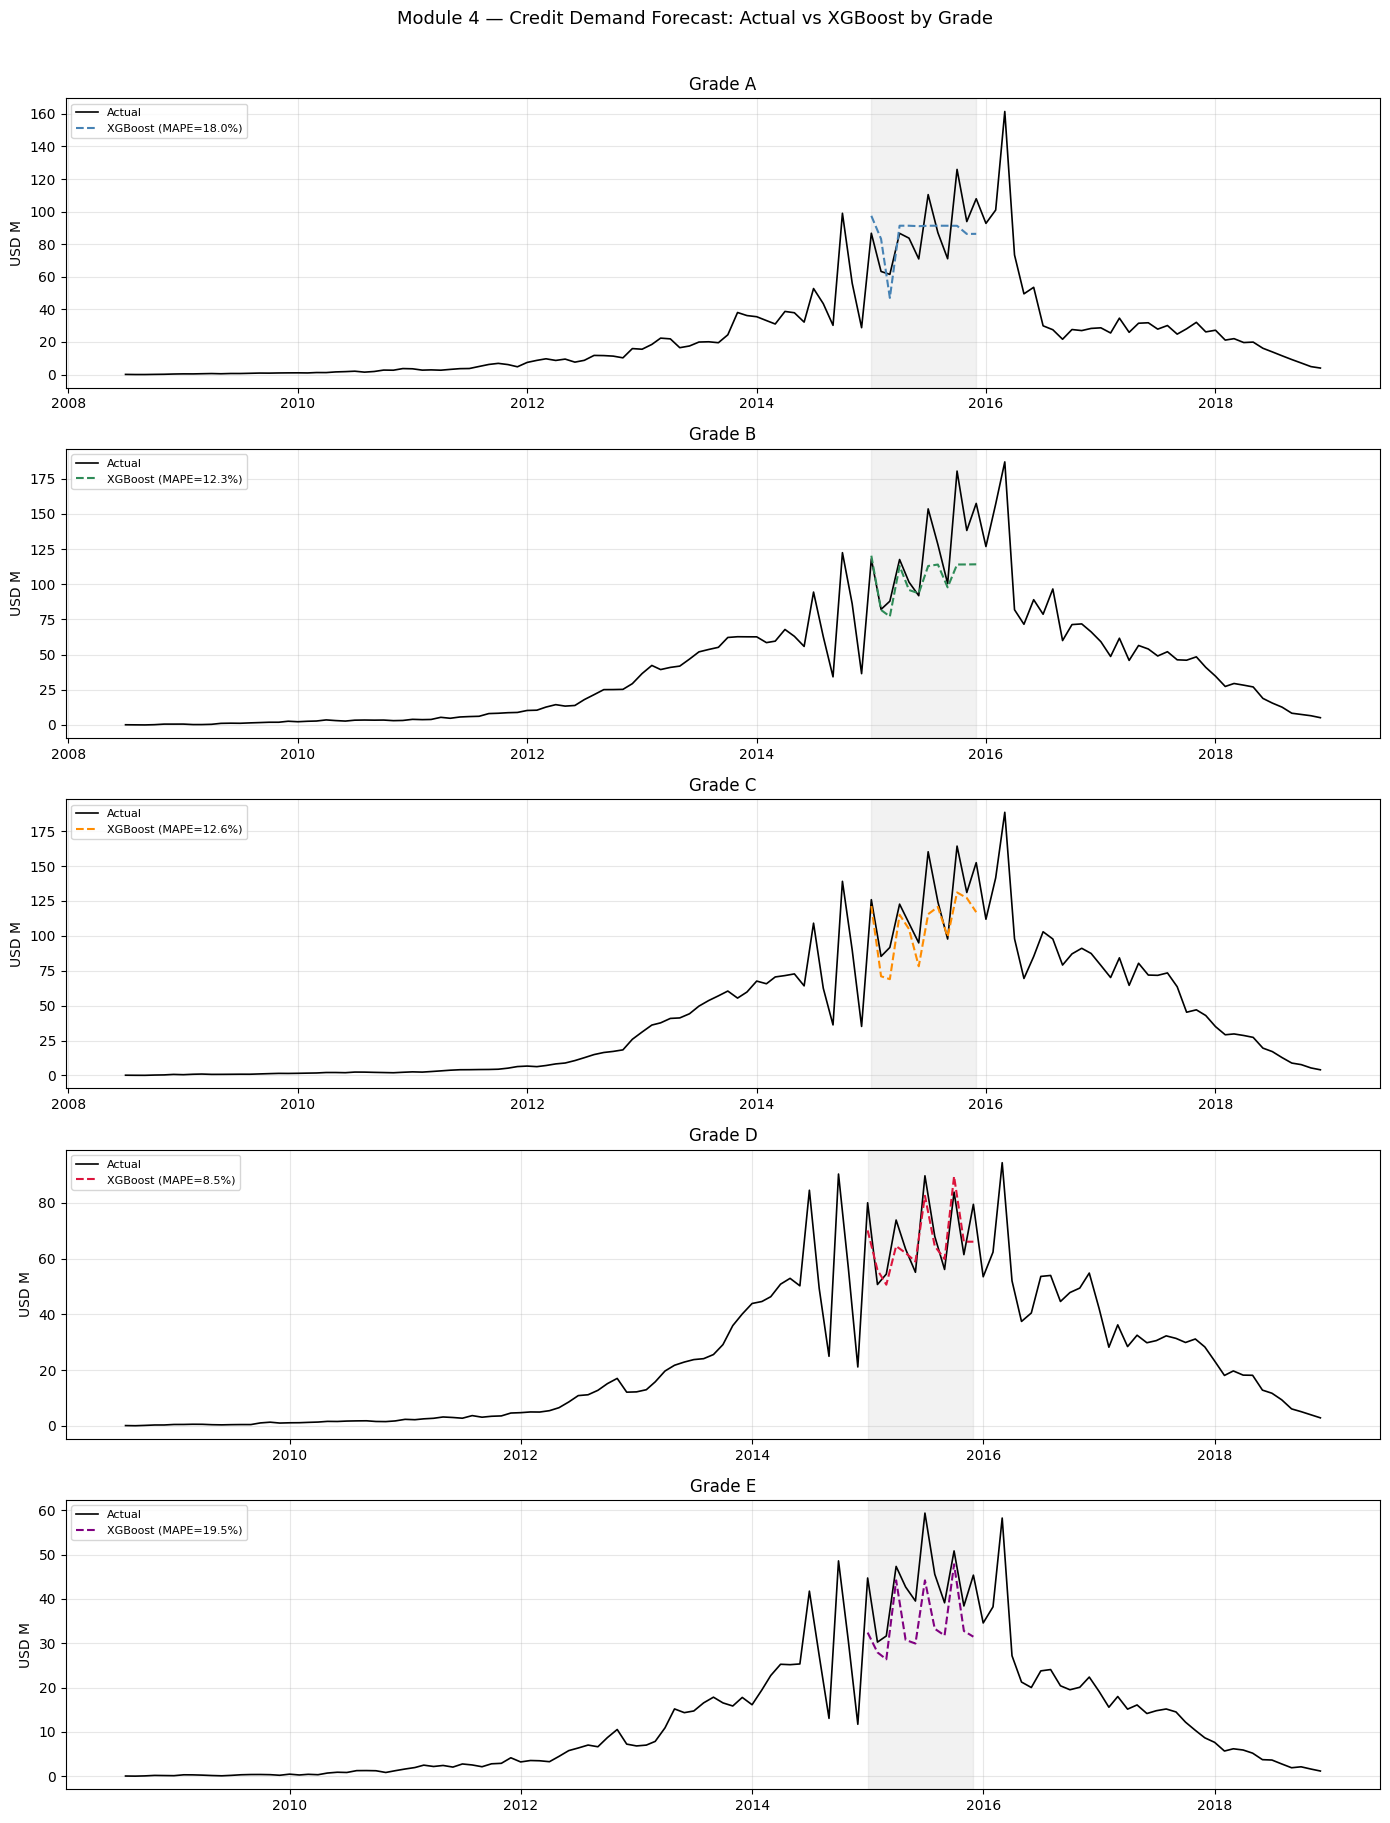

Forecast plot saved to reports/


In [8]:
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=False)
colors = {'A': 'steelblue', 'B': 'seagreen', 'C': 'darkorange', 'D': 'crimson', 'E': 'purple'}

for i, grade in enumerate(GRADES):
    ax       = axes[i]
    gdf      = grade_data[grade]
    sp       = splits[grade]
    y_pred   = all_results[grade]['XGBoost']['y_pred']
    mape     = all_results[grade]['XGBoost']['mape']

    ax.plot(gdf['month_start'], gdf[TARGET],
            color='black', linewidth=1.2, label='Actual')
    ax.plot(sp['test_dates'], y_pred,
            '--', color=colors[grade], linewidth=1.5,
            label=f'XGBoost (MAPE={mape:.1f}%)')
    ax.axvspan(sp['test_dates'].iloc[0], sp['test_dates'].iloc[-1],
               alpha=0.1, color='gray')
    ax.set_title(f'Grade {grade}')
    ax.set_ylabel('USD M')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Module 4 — Credit Demand Forecast: Actual vs XGBoost by Grade',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('reports/module4_forecast_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()
print('Forecast plot saved to reports/')

## 9. MAPE Heatmap — Model × Grade

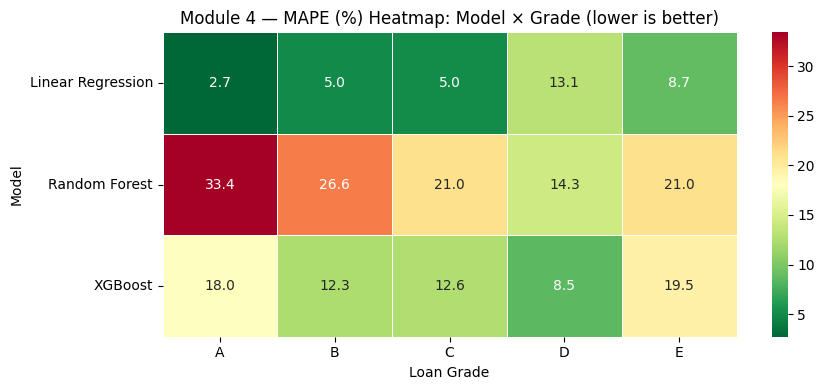

MAPE heatmap saved to reports/


In [9]:
# Build MAPE matrix: rows = models, cols = grades
model_names = ['Linear Regression', 'Random Forest', 'XGBoost']
mape_matrix = pd.DataFrame(
    index=model_names,
    columns=GRADES,
    dtype=float
)

for grade in GRADES:
    for model_name in model_names:
        mape_matrix.loc[model_name, grade] = all_results[grade][model_name]['mape']

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    mape_matrix.astype(float),
    annot=True, fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Module 4 — MAPE (%) Heatmap: Model × Grade (lower is better)')
ax.set_xlabel('Loan Grade')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig('reports/module4_mape_heatmap.png', dpi=150)
plt.show()
print('MAPE heatmap saved to reports/')

## 10. Save Models

In [10]:
for grade in GRADES:
    joblib.dump(all_models[grade]['xgb'],    f'models/module4_xgb_grade{grade}.pkl')
    joblib.dump(all_models[grade]['rf'],     f'models/module4_rf_grade{grade}.pkl')
    joblib.dump(all_models[grade]['lr'],     f'models/module4_lr_grade{grade}.pkl')
    joblib.dump(all_models[grade]['scaler'], f'models/module4_scaler_grade{grade}.pkl')

joblib.dump(FEATURES, 'models/module4_features.pkl')

# Save grade monthly data for dashboard
grade_monthly.to_csv('data/processed/grade_monthly_demand.csv', index=False)

print('All Module 4 models saved to models/')

All Module 4 models saved to models/
